In [28]:
import collections, itertools, random      
import scipy, tqdm, matplotlib
import numpy as np     
import matplotlib.pyplot as plt         
random.seed(0)
np.random.seed(0)

Example notebook comparing QDRIFT-PIMC with regular trotterization, as discussed in our paper (<font color='red'>arxiv:INSERTNUMBER [John M. Martyn, Joshua Lin, Neill C. Warrington, Isaac L. Chuang, Andrew J. Daley]</font>). The system studied is the longrange Ising model on $N$ sites, defined by the spin-$\frac{1}{2}$ Hamiltonian:

$$\hat{H} = \hat{T} + \hat{V}; \qquad \hat{T} = -\sum_{i=1}^N h \hat{T}_i, \quad \hat{V} = -\sum_{i,j = 1, i \neq j}^N \frac{J}{|i-j|^2} \hat{V}_{i,j};$$

$$\hat{T}_i = -\sigma^x_i,\quad \hat{V}_{i,j} = -\sigma^z_i \sigma^z_j$$


 

 

for parameters $h,J > 0$ where $V_{i,j}$ are individual 'potential' coupling terms, and $T_i$ are 'kinetic' operators on each of the spin degrees of freedom. 
Standard 2nd-order trotterization of the Euclidean path integral with $N_t$ timeslices proceeds by inserting complete basis states in the following fashion:
$$Z =  \sum_{\vec{x}_1,\dots,\vec{x}_{N_t}}\langle \vec{x}_1 | e^{-\frac{\mathrm{d}t}{2}\hat{V}} e^{-\mathrm{d}t \hat{T}} e^{-\frac{\mathrm{d}t}{2}\hat{V}} |\vec{x}_2 \rangle \langle \vec{x}_2 | e^{-\frac{\mathrm{d}t}{2}\hat{V}} e^{-\mathrm{d}t \hat{T}} e^{-\frac{\mathrm{d}t}{2}\hat{V}} |\vec{x}_3 \rangle \dots \langle \vec{x}_{N_t} | e^{-\frac{\mathrm{d}t}{2}\hat{V}} e^{-\mathrm{d}t \hat{T}} e^{-\frac{\mathrm{d}t}{2}\hat{V}} |\vec{x}_1\rangle $$
whereas QDrift-PIMC proceeds by averaging over 'patterns', which consists of a choice of $N_t$ operators $\hat{O}_\alpha$, $\alpha \in \{1,\dots,N_t\}$ independently drawn from $\{\hat{T}_i : 1 \leq i \leq N \} \cup \{ \hat{V}_{i,j} : 1 \leq i \neq j \leq N\}$ according to the distribution:
$$p(\hat{T}_i) = \frac{h}{\lambda}, \quad p(\hat{V}_{i,j}) = \frac{J}{|i-j|^2\lambda}$$
where $\lambda$ is a normalization constant. Symmetric QDrift-PIMC is the situation where the pattern is forced to be symmetric ($\hat{O}_\alpha = \hat{O}_{N_t - \alpha + 1}$), whereas Asymmetric QDrift-PIMC is the situation where all of the operators are independently drawn. 
The partition function is then given by:
$$ Z = \sum_{\hat{O}_1,\dots,\hat{O}_{N_t} \sim p} \mathrm{Tr}\left[e^{-\mathrm{d}t\ \hat{O}_1} e^{-\mathrm{d}t\ \hat{O}_2} \dots e^{-\mathrm{d}t\ \hat{O}_{N_t}}\right]$$
and in either Symmetric or Asymmetric cases, local observables $\hat{\mathcal{O}}$ can be evaluated as:
$$\langle \hat{\mathcal{O}} \rangle = \sum_{\hat{O}_1,\dots,\hat{O}_{N_t} \sim p} \frac{\mathrm{Tr}\left[\hat{\mathcal{O}} e^{-\mathrm{d}t\ \hat{O}_1} e^{-\mathrm{d}t\ \hat{O}_2} \dots e^{-\mathrm{d}t \ \hat{O}_{N_t}} \right] }{\mathrm{Tr}\left[e^{-\mathrm{d}t\ \hat{O}_1} e^{-\mathrm{d}t\ \hat{O}_2} \dots e^{-\mathrm{d}t \ \hat{O}_{N_t}}\right]}$$
Note that complete basis states on each spin are only inserted after kinetic terms.

# Regular QDrift

In [29]:
def generate_patterns(L,J,h,Nt,Npattern,symmetric):
    """
    Generates a number of patterns, for a given choice of parameters. 
    A "pattern" is a choice of operators, for example 
    [sigma^z_0 sigma^z_3, sigma^x_2, sigma^x_4, sigma^z_3 sigma^z_5, sigma^z_5 sigma^z_7, dots]
    according to the appropriate probability distribution. This is stored in the code as 
    [(0,3),2,4,(3,5),(5,7),...], where a tuple of two numbers refers to the corresponding $V_{i,j}$
    operator, and a single integer refers to the corresponding $T_i$ operator (note that whilst the
    paper and the markdown text above is 1-indexed, the code is all 0-indexed)
    
    Args:
        L (int)          : Number of spins
        J (float)        : Potential coupling in the hamiltonian
        h (float)        : kinetic term coupling in the hamiltonian
        Nt (int)         : number of timesteps
        Npattern (int)   : how many patterns to generate
        symmetric (bool) : If true, returns symmetric patterns. Otherwise, returns general patterns
        
    Returns:
        patterns : list of patterns
    """
    if symmetric:
        pj       = [J/(i-j)**2 if i != j else 0 for i in range(L) for j in range(L)] + [h]*L
        patterns = [random.choices([(i,j) for i in range(L) for j in range(L)] + list(range(L)),pj,k=Nt//2)\
                            for _ in range(Npattern)]
        patterns = [x + list(reversed(x)) for x in patterns]
        return patterns
    else:
        pj       = [J/(i-j)**2 if i != j else 0 for i in range(L) for j in range(L)] + [h]*L
        patterns = [random.choices([(i,j) for i in range(L) for j in range(L)] + list(range(L)),pj,k=Nt)\
                            for _ in range(Npattern)]
        return patterns

In [30]:
def numspins(L,p,return_xcounts=False):
    """
    For a given pattern p, counts the total number of spins needed. 
    See Figure 2 of the paper.
    
    Args:
        L (int)        : Number of spins in the lattice
        p (list)       : pattern generated from generate_patterns
        return_xcounts : Bool, whether or not to return xcounts 
        
    Returns:
        numspins : Number of conglomerate spins
        xcounts  : Dictionary that maps a given spin index (key) to how many
                   sigma^x terms appear for that spin index. The number of spins 
                   required for spin index i is then xcounts[i] + 1
    """
    xcounts  = collections.Counter([x for x in p if type(x) is int])
    numspins = 0
    for k,v in xcounts.items():
        numspins = numspins + max(v,1)
    for i in range(L):
        if i not in xcounts.keys():
            numspins = numspins + 1
    if return_xcounts:
        return numspins,xcounts
    return numspins

In [31]:
def av_numspins(L,J,h,Nt,symmetric):
    """
    Computes the average number of sites (averaged over pattern choices) for a given set of parameters. 

    Args :
      L         : Number of spatial spins
      J,h       : Parameters in the Hamiltonian
      Nt        : Number of timesteps
      symmetric : Whether or not it is symmetric, or asymmetric QDrift

    Returns :
      Number of sites
    """
    if symmetric:
        lambda_  = 2*J*sum([1/(i-j)**2  for i in range(L) for j in range(i+1,L)]) + h*L
        return L*(Nt*(h/lambda_) + (1-(h/lambda_))**(Nt//2))
    else:
        lambda_  = 2*J*sum([1/(i-j)**2  for i in range(L) for j in range(i+1,L)]) + h*L
        return L*(Nt*(h/lambda_) + (1-(h/lambda_))**Nt)

In [32]:
def interpret_pattern(L,J,h,p,obs,dt,verbose=False,return_aux=False):
    """For a given pattern p, interprets the block-spin conglomerates for p,
    and also derives all the local actions for each of the block-spins. 
    
    Args:
        L                     : number of spins
        p                     : a pattern
        obs                   : a function that takes in a list of L spins, [+-1, +-1,...,+-1] 
                                and spits out a single number. This is the local observable. 
        verbose (optional)    : whether or not to print out debug information
        return_aux (optional) : whether or not to return spinmap and r_spinmap
    
    Returns:
        local_updates: local_updates[i] is a function that takes in a numspins-length list of [+-1,...,+-1] 
                        and updates the i-th spin according to the local action. 
        obs_: A function that evaluates the average of obs on a given conglomerate configuration. 
    """
    
    lambda_           = 2*J*sum([1/(i-j)**2  for i in range(L) for j in range(i+1,L)]) + h*L
    Nt                = len(p)
    numspins_,xcounts = numspins(L,p,return_xcounts=True) 
    
    #There's a map that takes spin_index and time_index -> conglomerate_index, this is called spinmap
    #There's a reverse map that tells me which site a given conglomerate inhabits, this is r_spinmap
    at = 0; 
    spinmap = []; r_spinmap = [];
    for i in range(L):
        spinmap.append([])
        num_on_this_spin = 0
        for j in range(Nt):
            spinmap[-1].append(at)
            if at == len(r_spinmap):
                r_spinmap.append(i)
            if p[j] == i:
                at = at + 1
                num_on_this_spin = num_on_this_spin + 1
                if num_on_this_spin == xcounts[i]:
                    at = at - xcounts[i]
        at = at + max(1,xcounts[i])
    if verbose:
        print("spinmap:")
        for i in range(L):
            print(",".join([str(x) for x in spinmap[i]]))
        print("r_spinmap:",r_spinmap)
    
    
    local_updates = []
    for i in range(numspins_):
        #Abusing closures in the returned local_update functions
        
        lst_Z = [] #Targets for Z's
        lst_X = [] #Targets for X's

        #For each operator in the pattern
        for j in range(Nt):
            #If the operator is an X acting on the spin index corresponding to my current conglomerate, 
            #and it so happens that there is only one X acting on this spin index (so that the conglomerate
            #wraps all the way around), then you need to have an X interaction between the spin and itself
            #BUT note that this doesn't actually have any consequences on the action, so you don't need 
            #to keep track of it.
            if p[j] == r_spinmap[i] and spinmap[r_spinmap[i]][j] == i and spinmap[r_spinmap[i]][(j+1)%Nt] == i:
                pass
            elif p[j] == r_spinmap[i] and spinmap[r_spinmap[i]][j] == i:
                #Otherwise, the X couples spin to some other spin:
                lst_X.append(spinmap[r_spinmap[i]][(j+1)%Nt])
            elif p[j] == r_spinmap[i] and spinmap[r_spinmap[i]][(j+1)%Nt] == i:
                lst_X.append(spinmap[r_spinmap[i]][j])
            if type(p[j]) == tuple and r_spinmap[i] in p[j] and spinmap[r_spinmap[i]][j] == i:
                #Else, I'm in a ZZ operator situation:
                lst_Z.append(spinmap[[x for x in p[j] if x != r_spinmap[i]][0]][j])
        
        def local_update(s,i=i,lst_Z=lst_Z,lst_X=lst_X):
            prob_m1 = 1; prob_p1 = 1;
            for j in lst_Z:
                prob_m1 = prob_m1 * np.exp((-1)*s[j]*lambda_*dt)
                prob_p1 = prob_p1 * np.exp(   1*s[j]*lambda_*dt)
            for j in lst_X:
                prob_m1 = prob_m1 * 0.5*( (-1)*s[j]*np.exp(-lambda_*dt) + np.exp(+lambda_*dt) )
                prob_p1 = prob_p1 * 0.5*( (+1)*s[j]*np.exp(-lambda_*dt) + np.exp(+lambda_*dt) )
            if random.random() < prob_p1/(prob_p1+prob_m1):
                s[i] =  1
            else:
                s[i] = -1
                
            if verbose:#closure
                print("check:",i,lst_Z,lst_X)
                print("probabilities:",prob_m1,prob_p1)
                
            return s
                
        local_updates.append(local_update)
        
    #For a local obs, 
    def obs_(s):
        #This only inserts at the symmetric locations
        #Note that you could insert everywhere to volume average for the asymmetric configurations
        return np.average([obs([s[x[i]] for x in spinmap]) for i in [0, Nt//2]])
        
    if return_aux:
        return local_updates,obs_,spinmap,r_spinmap
    return local_updates,obs_

In [33]:
def qdrift_heatbath(s,local_updates):
    """
    One MCMC update done by the heatbath algorithm: i.e. loop over the conglomerate spins, 
    and for each update the spin according to the appropriate action. 

    Args:
        s             : a configuration of spins, stored as a 1D list
        local_updates : local_update functions that update each spin, as returned by 
                        interpret_pattern

    Returns
        A new configuration, after Monte Carlo update has been applied to each spin.
    """
    for i in range(len(s)):
        s = local_updates[i](s)
    return s

In [34]:
def qdrift_MCMC(L,J,h,
                Npattern,NMCMC,Nburn,
                beta,Nt,symmetric):
    """
    Args: 
      L         : Number of spins
      J,h       : parameters of the Hamiltonian
      NPattern  : How many patterns to sample in QDrift
      NMCMC     : Number of MCMC updates to use
      Nburn     : Number of configurations to discard to thermalise
      beta      : 1/temperature 
      Nt        : Number of temporal lattice spacings?!
      symmetric : whether or not to use symmetric patterns

    Returns:
      A tuple, containing average value for the observable, the associated statistical error,
      and an errorbar associated to the different pattern samplings. 
    """
    
    dt       = beta/Nt    
    obs_l    = lambda s : sum([J*s[i]*s[j]/(i-j)**2 for i,j in itertools.product(range(L),repeat=2) if i != j])
    im       = L//2
    patterns = generate_patterns(L=L,J=J,h=h,Nt=Nt,Npattern=Npattern,symmetric=symmetric)
    o_ = [];
    for p in tqdm.tqdm(patterns):
        local_actions,obs = interpret_pattern(L,J,h,p,obs_l,dt)
        #Initial conglomerate spin configuration 
        s = [1]*len(local_actions)
        allobs = []
        for i in range(NMCMC+Nburn):
            for _ in range(10):
                #Update the conglomerate spin configuration
                s = qdrift_heatbath(s,local_actions)
            #I'm putting some burn-in in
            if i >= Nburn:
                #Measure the observable
                allobs.append(obs(s))

        #Record the average measured observable
        o_.append(allobs)
        
    pattern_average          = np.average(o_,axis=1)
    outside_pattern_variance = np.var(np.average(o_,axis=1))/(Npattern)
    inside_pattern_variance  = np.average(np.var(o_,axis=1))/(Npattern*NMCMC)
    
    return np.average(o_), inside_pattern_variance, outside_pattern_variance

In [35]:
Npattern = 400
NMCMC    = 200
Nburn    = 10
L        = 32
J        = 0.1
h        = 1.0
beta     = 8

In [ ]:
x_list = [240,300,370,500,750,1000,2000]
o_list_s = [];   o_list_a = [];
ei_list_s  = []; ei_list_a = [];
eo_list_s  = []; eo_list_a = [];
for x in x_list:
    o_,ei_,eo_ = qdrift_MCMC(L=L,J=J,h=h,
                    Npattern=Npattern,NMCMC=NMCMC,Nburn=Nburn,
                    beta=beta,Nt=x,symmetric=True)
    o_list_s.append(o_)
    ei_list_s.append(ei_)
    eo_list_s.append(eo_)
    
    o_,ei_,eo_ = qdrift_MCMC(L=L,J=J,h=h,
                    Npattern=Npattern,NMCMC=NMCMC,Nburn=Nburn,
                    beta=beta,Nt=x,symmetric=False)
    o_list_a.append(o_)
    ei_list_a.append(ei_)
    eo_list_a.append(eo_)

  8%|██████████████▎                                                                                                                                                               | 33/400 [00:12<02:18,  2.65it/s]

In [ ]:
#Performs a linear + quadratic fit to the dt dependence of the observable, for the symmetric-QDrift case
popt_qdrift_s,pcov_qdrift_s = scipy.optimize.curve_fit(lambda x,a,b,c : a + b*x + c*x**2,
                          1/np.array(x_list)[2:],
                          np.array(o_list_s)[2:],
                          sigma=np.sqrt(np.array(ei_list_s)+np.array(eo_list_s))[2:],
                          absolute_sigma=True,
                          p0=[1,1,1])

In [ ]:
#Performs a linear + quadratic fit to the dt dependence of the observable, for the antisymmetric-QDrift case
popt_qdrift_a,pcov_qdrift_a = scipy.optimize.curve_fit(lambda x,a,b,c : a + b*x + c*x**2,
                         1/np.array(x_list)[2:],
                          np.array(o_list_a)[2:],
                          sigma=np.sqrt(np.array(ei_list_a)+np.array(eo_list_a))[2:],
                          absolute_sigma=True,
                         p0=[1,1,1])

# Regular Trotter

In [ ]:
def trotter_heatbath(s,L,J,h,dt):
    """
    assumes s is a (Nt,Nx) shaped array, and trotter updates it

    Args
        s  : a configuration of spins
        L  : number of spins
        J  : parameter of the transverse Ising model
        h  : parameter of the transverse Ising model
        dt : timestep 

    Returns:
        a new configuration, after applying monte carlo updates to each spin. 
    """
    Nt,Nx = s.shape
    for i,j in itertools.product(range(Nt),range(Nx)):
        Sp = -np.log(1 + s[(i+1)%Nt,j]*np.exp(-2*h*dt)) + \
                -np.log(1 + s[(i-1)%Nt,j]*np.exp(-2*h*dt))
        Sm = -np.log(1 - s[(i+1)%Nt,j]*np.exp(-2*h*dt)) + \
                -np.log(1 - s[(i-1)%Nt,j]*np.exp(-2*h*dt))
        for k in range(L):
            if j == k:
                continue
            Sp = Sp - 2 * dt * (J/(j-k)**2) * s[i,k]
            Sm = Sm + 2 * dt * (J/(j-k)**2) * s[i,k]
        if np.random.random() < np.exp(-Sp)/(np.exp(-Sp) + np.exp(-Sm)):
            s[i,j] = +1
        else:
            s[i,j] = -1
    return s
    

In [ ]:
def trotter_MCMC(L,J,h,
                 NMCMC,Nupdate,
                 beta,Nt):
    """
    A general wrapper performing a monte carlo simulation for the trotter scheme

    Args:
        L       : number of spins
        J,h     : arguments of the transverse Ising model
        NMCMC   : number of measurements to perform
        Nupdate : number of monte carlo updates performed in-between each measurement
        beta    : total Euclidean time extent 
        Nt      : how many timeslices to discretise the total Euclidean time extent into

    Returns:
        a tuple containing average measurement of the potential energy, and associated standard error. 
    """
    dt       = beta/Nt
    s        = np.ones((Nt,L),dtype=int)
    obs_l    = lambda s : sum([J*s[i]*s[j]/(i-j)**2 for i,j in itertools.product(range(L),repeat=2) if i != j])
    obs      = []
    for _ in tqdm.tqdm(range(NMCMC)):
        for __ in range(Nupdate):
            s = trotter_heatbath(s,L,J,h,dt)
        obs.append(np.average([obs_l(s[i]) for i in range(Nt)]))
        
    return np.average(obs),np.var(obs)/(NMCMC)

In [ ]:
L        = 32   # Number of spins in the lattice
J        = 0.1  # J coefficient of the hamiltonian
h        = 1.0  # h coefficient of the hamiltonian
NMCMC    = 200  # Number of measurements
Nupdate  = 10   # Number of MCMC updates inbetween measurements
beta     = 8.0  # inverse temperature

In [ ]:
Nt_list_trotter = [6,8,10,16,24,48]
o_list_trotter  = []
e_list_trotter  = []
for Nt in Nt_list_trotter:
    o_,e_ = trotter_MCMC(L,J,h,NMCMC,Nupdate,beta,Nt)
    o_list_trotter.append(o_)
    e_list_trotter.append(e_)

In [ ]:
#Performs a quadratic fit to the dt-dependence of the observable
popt_trotter,pcov_trotter = scipy.optimize.curve_fit(lambda x,a,b : a + b*x**2,
                                                     1/np.array(Nt_list_trotter)[2:],
                                                     np.array(o_list_trotter)[2:],
                                                     sigma=np.sqrt(e_list_trotter)[2:],
                                                     absolute_sigma=True,
                                                     p0=[1,1])

# Plots

In [ ]:
matplotlib.rcParams['font.size']   = 12
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif']  = ['cmtt10']
matplotlib.rcParams["text.usetex"] = True
colors                             = ['steelblue','darkorange','forestgreen']

In [ ]:
def plot(axs,r_meas,r_interp,numspins,numops,meas,color,label,inner_yerr,popt,pcov,outer_yerr=None,alpha=1.0,shift=0.0,yshift=0.0):
    """
    A helpfer function to create the plot that appears in the paper
    """

    if len(popt) == 3:
        y = (popt[0] + (1/r_interp)*popt[1] + (1/r_interp**2)*popt[2])
    else:
        y = (popt[0] + (1/r_interp**2)*popt[1])

    # 1σ uncertainty on the fit prediction
    def fit_error(r, pcov):
        if len(popt) == 3:
            J = np.column_stack([np.ones_like(r), 1.0/r, 1.0/r**2])
        else:
            J = np.column_stack([np.ones_like(r), 1.0/r**2])
        var = np.einsum("ij,jk,ik->i", J, pcov, J)
        return np.sqrt(var)
    sigma_y = fit_error(r_interp, pcov)
    
    for i,x,f in zip(range(2),[numspins,numops],[1e3,1e4]):
        axs[i].errorbar(f/x(r_meas),meas-yshift,yerr=inner_yerr,
                        fmt='^',capsize=5,color=color,label=label,mfc='none',alpha=alpha)
        if outer_yerr is not None:
            axs[i].errorbar(f/x(r_meas),meas-yshift,yerr=np.sqrt(inner_yerr + outer_yerr),
                        fmt='^',capsize=5,color=color,mfc='none',alpha=alpha)

        axs[i].plot(f/x(r_interp),y-yshift,zorder=-100,color=color,linestyle='-',alpha=0.5*alpha)

        # 1σ error band on the fit
        axs[i].fill_between(f/x(r_interp), y - sigma_y-yshift, y + sigma_y-yshift,
                            color=color, alpha=0.2*alpha, edgecolor='none',
                            zorder=-101)

        # Extrapolated value at x = 0
        y_inf = popt[0]
        y_inf_err = np.sqrt(pcov[0, 0])
        axs[i].errorbar(f*shift/1e3, y_inf-yshift, yerr=y_inf_err,
                        fmt='o', color=color, capsize=2, mfc=color,
                        markersize=3, zorder=10,alpha=alpha)

    

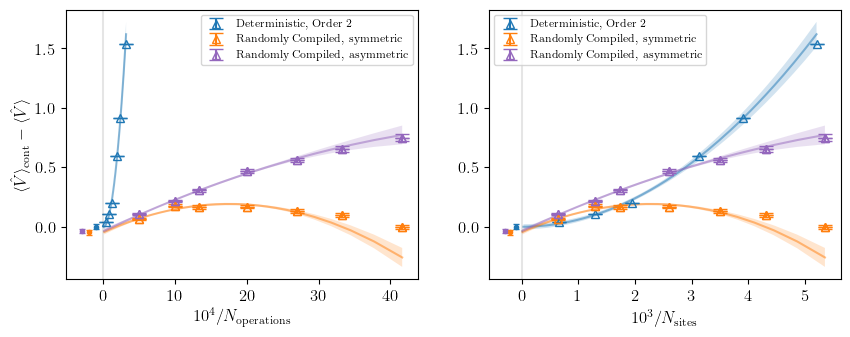

In [27]:
fig,axs = plt.subplots(1,2,figsize=(10,3.5))

plot(list(reversed(axs)),np.array(Nt_list_trotter),np.linspace(min(Nt_list_trotter),1000,4000),lambda r : L*r,lambda r : r*(L + L*(L-1)/2),
     np.array(o_list_trotter),'C0','Deterministic, Order 2',np.array(e_list_trotter),popt_trotter,pcov_trotter,shift=-0.1,
    yshift=popt_trotter[0])
plot(list(reversed(axs)),np.array(x_list),np.linspace(min(x_list),100000,4000),lambda r : av_numspins(L,J,h,r,True),lambda r : r,
     np.array(o_list_s),'C1','Randomly Compiled, symmetric',np.array(ei_list_s),popt_qdrift_s,pcov_qdrift_s,outer_yerr=np.array(eo_list_s),alpha=1.0,shift=-0.2,
    yshift=popt_trotter[0])
plot(list(reversed(axs)),np.array(x_list),np.linspace(min(x_list),100000,4000),lambda r : av_numspins(L,J,h,r,True),lambda r : r,
     np.array(o_list_a),'C4','Randomly Compiled, asymmetric',np.array(ei_list_a),popt_qdrift_a,pcov_qdrift_a,outer_yerr=np.array(eo_list_a),alpha=1.0,shift=-0.3,
    yshift=popt_trotter[0])

axs[0].set_ylabel(r"$\langle \hat{V} \rangle_\mathrm{cont} - \langle \hat{V}\rangle$")
    
axs[1].set_xlabel(r"$10^3/N_\mathrm{sites}$")
axs[0].set_xlabel(r"$10^4/N_\mathrm{operations}$")

axs[0].legend(loc='upper right',fontsize=8)
axs[1].legend(loc='upper left',fontsize=8)

axs[0].axvline(0,color='k',alpha = 0.1)
axs[1].axvline(0,color='k',alpha = 0.1)

plt.savefig("clim.pdf",bbox_inches='tight')

plt.show()